In [3]:
import math
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.figure_factory as ff
from datetime import datetime
from sklearn import set_config
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline

# Tema Principal
from sklearn.decomposition import PCA

In [4]:
from pathlib import Path
import pandas as pd

base = Path.cwd()
ruta_catalogo = base / "iter_00_cpv2020" / "catalogos" / "tam_loc.csv.csv"
catalogo = pd.read_csv(ruta_catalogo)

In [27]:
ruta_dic = base / "iter_00_cpv2020\diccionario_datos\diccionario_datos_iter_00CSV20.csv"
diccionario = pd.read_csv(ruta_dic)

In [19]:
ruta_df = base / "iter_00_cpv2020\conjunto_de_datos\conjunto_de_datos_iter_00CSV20.csv"
df = pd.read_csv(ruta_df)

C:\Users\randy\AppData\Local\Temp\ipykernel_20256\971871720.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_df)


In [25]:
catalogo.head(40)

,tam_loc,descripcion
0,1,1 a 249 habitantes
1,2,250 a 499 habitantes
2,3,500 a 999 habitantes
3,4,1 000 a 2 499 habitantes
4,5,2 500 a 4 999 habitantes
5,6,5 000 a 9 999 habitantes
6,7,10 000 a 14 999 habitantes
7,8,15 000 a 29 999 habitantes
8,9,30 000 a 49 999 habitantes
9,10,50 000 a 99 999 habitantes


In [28]:
diccionario.head(15)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,CENSO DE POBLACIÓN Y VIVIENDA 2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Relación de indicadores,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Cuarta edición,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Núm.,Indicador,Descripción,Mnemónico,Rangos,Longitud,NaN,NaN,NaN,NaN
4,1,Clave de entidad federativa,Código que identifica a la entidad federativa....,ENTIDAD,00…32,2,NaN,NaN,NaN,NaN
5,2,Entidad federativa,Nombre oficial de la entidad federativa.,NOM_ENT,Alfanumérico,50,NaN,NaN,NaN,NaN
6,3,Clave de municipio o demarcación territorial,Código que identifica al municipio o demarcaci...,MUN,000…570,3,NaN,NaN,NaN,
7,4,Municipio o demarcación territorial,Nombre oficial del municipio o demarcación ter...,NOM_MUN,Alfanumérico,50,NaN,NaN,NaN,NaN
8,5,Clave de localidad,Código que identifica a la localidad al interi...,LOC,0000…9999,4,NaN,NaN,NaN,NaN
9,6,Localidad,Nombre con el que se reconoce a la localidad d...,NOM_LOC,Alfanumérico,70,NaN,NaN,NaN,NaN


In [29]:
diccionario = diccionario.iloc[3:].reset_index(drop=True)

diccionario.columns = diccionario.iloc[0]

diccionario = diccionario.iloc[1:].reset_index(drop=True)
pd.set_option('display.max_rows', None)
display(diccionario)

,Núm.,Indicador,Descripción,Mnemónico,Rangos,Longitud,NaN,NaN,NaN,NaN
0,1,Clave de entidad federativa,Código que identifica a la entidad federativa....,ENTIDAD,00…32,2,NaN,NaN,NaN,NaN
1,2,Entidad federativa,Nombre oficial de la entidad federativa.,NOM_ENT,Alfanumérico,50,NaN,NaN,NaN,NaN
2,3,Clave de municipio o demarcación territorial,Código que identifica al municipio o demarcaci...,MUN,000…570,3,NaN,NaN,NaN,
3,4,Municipio o demarcación territorial,Nombre oficial del municipio o demarcación ter...,NOM_MUN,Alfanumérico,50,NaN,NaN,NaN,NaN
4,5,Clave de localidad,Código que identifica a la localidad al interi...,LOC,0000…9999,4,NaN,NaN,NaN,NaN
5,6,Localidad,Nombre con el que se reconoce a la localidad d...,NOM_LOC,Alfanumérico,70,NaN,NaN,NaN,NaN
6,7,Longitud,"Ubicación de la localidad expresada en grados,...",LONGITUD,Caracter,16,NaN,NaN,NaN,NaN
7,8,Latitud,"Ubicación de la localidad expresada en grados,...",LATITUD,Caracter,15,NaN,NaN,NaN,NaN
8,9,Altitud,"Altura a la que se encuentra una localidad, re...",ALTITUD,Caracter,4,NaN,NaN,NaN,NaN
9,1,Población total,Total de personas que residen habitualmente en...,POBTOT,0...999999999,9,NaN,NaN,NaN,NaN


In [21]:
df.head()

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,...,30775898,18307193,15211306,6616141,4047100,1788552,3170894,15108204,852871,*
1,0,Total nacional,0,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,250354,...,47005,8385,18981,1732,1113,12775,14143,51293,7154,*
2,0,Total nacional,0,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,147125,...,25581,5027,11306,971,708,8247,10065,29741,5283,*
3,1,Aguascalientes,0,Total de la entidad Aguascalientes,0,Total de la Entidad,NaN,NaN,NaN,1425607,...,359895,236003,174089,98724,70126,6021,15323,128996,1711,*
4,1,Aguascalientes,0,Total de la entidad Aguascalientes,9998,Localidades de una vivienda,NaN,NaN,NaN,3697,...,732,205,212,48,41,39,62,530,20,*


In [31]:
df.shape

(195662, 286)

In [33]:
df.isna().sum().sort_values(ascending=False).head(20)

LONGITUD      6230
LATITUD       6230
ALTITUD       6230
REL_H_M        214
PROM_HNV       211
P15SEC_COF       0
GRAPROES_F       0
GRAPROES         0
P18YM_PB_M       0
P18YM_PB_F       0
P18YM_PB         0
P15SEC_COM       0
P15SEC_INM       0
P15SEC_CO        0
PEA              0
P15SEC_INF       0
P15SEC_IN        0
P15PRI_COM       0
P15PRI_COF       0
P15PRI_CO        0
dtype: int64

In [34]:
df.duplicated().sum()

0

In [23]:
from ctg_viz import check_data_completeness_nomnbrecompleto

In [42]:
check_data_completeness_nomnbrecompleto(df)

,columna,faltantes,completitud %,tipo,std,var,min,max,unicos,categoria
0,ENTIDAD,0,100.000000,int64,8.940159,7.992644e+01,0.0,32.0,33,continua
1,NOM_ENT,0,100.000000,object,NaN,NaN,NaN,NaN,33,otra
2,MUN,0,100.000000,int64,81.370934,6.621229e+03,0.0,570.0,571,continua
3,NOM_MUN,0,100.000000,object,NaN,NaN,NaN,NaN,2359,otra
4,LOC,0,100.000000,int64,1502.609425,2.257835e+06,0.0,9999.0,5201,continua
5,NOM_LOC,0,100.000000,object,NaN,NaN,NaN,NaN,102301,otra
6,LONGITUD,6230,96.815938,object,NaN,NaN,NaN,NaN,188832,otra
7,LATITUD,6230,96.815938,object,NaN,NaN,NaN,NaN,188428,otra
8,ALTITUD,6230,96.815938,object,NaN,NaN,NaN,NaN,5767,otra
9,POBTOT,0,100.000000,int64,293148.590389,8.593610e+10,1.0,126014024.0,7653,continua


In [45]:
import pandas as pd
import numpy as np

df2 = df.copy()
df2.columns = df2.columns.str.strip()

# Coordenadas (siempre numéricas)
coord_cols = ['LATITUD', 'LONGITUD', 'ALTITUD']
for c in coord_cols:
    if c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors='coerce')

# Solo columnas object
obj_cols = df2.select_dtypes(include='object').columns.difference(coord_cols)

for c in obj_cols:
    s = df2[c].astype(str).str.strip()

    # Limpieza típica de datos censales
    s_clean = (
        s.str.replace(',', '', regex=False)      # 1,234 -> 1234
         .str.replace(' ', '', regex=False)      # quita espacios internos
         .replace({'*': np.nan, 'N/D': np.nan, 'NA': np.nan, 'nan': np.nan, '': np.nan})
    )

    num = pd.to_numeric(s_clean, errors='coerce')

    # Convierte a numérica si >=80% de valores no nulos originales pudieron convertirse
    base = s_clean.notna().sum()
    ratio = (num.notna().sum() / base) if base > 0 else 0

    if ratio >= 0.80:
        df2[c] = num
    else:
        df2[c] = df2[c].astype('object')

# reemplaza tu df final
df = df2
print(df.dtypes.value_counts())




float64    277
int64        6
object       3
Name: count, dtype: int64


In [46]:
check_data_completeness_nomnbrecompleto(df)

,columna,faltantes,completitud %,tipo,std,var,min,max,unicos,categoria
0,ENTIDAD,0,100.000000,int64,8.940159,7.992644e+01,0.0,3.200000e+01,33,continua
1,NOM_ENT,0,100.000000,object,NaN,NaN,NaN,NaN,33,otra
2,MUN,0,100.000000,int64,81.370934,6.621229e+03,0.0,5.700000e+02,571,continua
3,NOM_MUN,0,100.000000,object,NaN,NaN,NaN,NaN,2359,otra
4,LOC,0,100.000000,int64,1502.609425,2.257835e+06,0.0,9.999000e+03,5201,continua
5,NOM_LOC,0,100.000000,object,NaN,NaN,NaN,NaN,102301,otra
6,LONGITUD,195662,0.000000,float64,NaN,NaN,NaN,NaN,0,discreta
7,LATITUD,195662,0.000000,float64,NaN,NaN,NaN,NaN,0,discreta
8,ALTITUD,6253,96.804183,float64,864.748685,7.477903e+05,-18.0,3.545000e+03,3167,continua
9,POBTOT,0,100.000000,int64,293148.590389,8.593610e+10,1.0,1.260140e+08,7653,continua


In [48]:
df = df.dropna(axis=1, how='all')


In [54]:
df = df.dropna().copy()


In [57]:
df.shape

(107958, 284)

In [58]:

id_cols = ['ENTIDAD','MUN','LOC','NOM_ENT','NOM_MUN','NOM_LOC']
X = df.drop(columns=[c for c in id_cols if c in df.columns], errors='ignore')
X = X.select_dtypes(include='number')

In [59]:
# 2) Score de importancia sin etiqueta (variabilidad)
std = X.std()
iqr = X.quantile(0.75) - X.quantile(0.25)
cv  = std / (X.mean().abs() + 1e-9)

score = pd.concat([std, iqr, cv], axis=1)
score.columns = ['std', 'iqr', 'cv']
score_rank = score.rank(pct=True).mean(axis=1)  # score combinado 0-1
score_rank = score_rank.sort_values(ascending=False)

Primero se depuran variables no analíticas (identificadores y texto. Después, la relevancia se estimó con un score combinado de variabilidad (std, IQR y CV), priorizando variables con mayor capacidad de discriminar diferencias entre municipios y para evitar redundancia y multicolinealidad, se aplicó un filtro de correlación alta (|r| > 0.90)

Este procedimiento permite que las variables seleccionadas:

Aporten señal estadística real (no variables casi constantes).
Sean complementarias entre sí (sin duplicar información).
Representen dimensiones estructurales de la marginación (educación, empleo, vivienda, acceso a servicios y condiciones sociodemográficas), facilitando su interpretación territorial.

In [62]:
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

selected = []
for var in score_rank.index:
    if not selected:
        selected.append(var)
        continue

    if (corr.loc[var, selected] <= 0.90).all():
        selected.append(var)

top_n = 30
top_vars = selected[:top_n]

print(f"Variables candidatas (top {top_n}):")
print(top_vars)

ranking_final = score_rank.loc[top_vars]
X_sel = X[top_vars].copy()
display(ranking_final)

Variables candidatas (top 30):
['P_18YMAS', 'PNACOE', 'VPH_CISTER', 'PDER_ISTE', 'PRESOE15', 'PAFIL_IPRIV', 'ALTITUD', 'REL_H_M', 'PHOG_IND', 'POB_AFRO', 'PDER_ISTEE', 'PAFIL_OTRAI', 'PAFIL_PDOM', 'POTRAS_REL', 'VIVPAR_UT', 'P15YM_AN_F', 'VPH_1CUART', 'VPH_NODREN', 'VPH_PISOTI', 'VPH_AGUAFV', 'VPH_LETR', 'VPH_SINTIC', 'PDER_IMSSB', 'VPH_S_ELEC', 'GRAPROES_F', 'GRAPROES_M', 'P3HLINHE', 'TAMLOC', 'VPH_NDEAED', 'PRO_OCUP_C']


P_18YMAS       0.862110
PNACOE         0.766787
VPH_CISTER     0.699041
PDER_ISTE      0.577938
PRESOE15       0.538369
PAFIL_IPRIV    0.508393
ALTITUD        0.507194
REL_H_M        0.468825
PHOG_IND       0.451439
POB_AFRO       0.434053
PDER_ISTEE     0.428058
PAFIL_OTRAI    0.423261
PAFIL_PDOM     0.412470
POTRAS_REL     0.370504
VIVPAR_UT      0.258393
P15YM_AN_F     0.257194
VPH_1CUART     0.245803
VPH_NODREN     0.172662
VPH_PISOTI     0.166667
VPH_AGUAFV     0.155276
VPH_LETR       0.145683
VPH_SINTIC     0.121103
PDER_IMSSB     0.103118
VPH_S_ELEC     0.067746
GRAPROES_F     0.064748
GRAPROES_M     0.059952
P3HLINHE       0.056355
TAMLOC         0.040767
VPH_NDEAED     0.033573
PRO_OCUP_C     0.022782
dtype: float64

Varianza explicada PC1+PC2: 0.5355


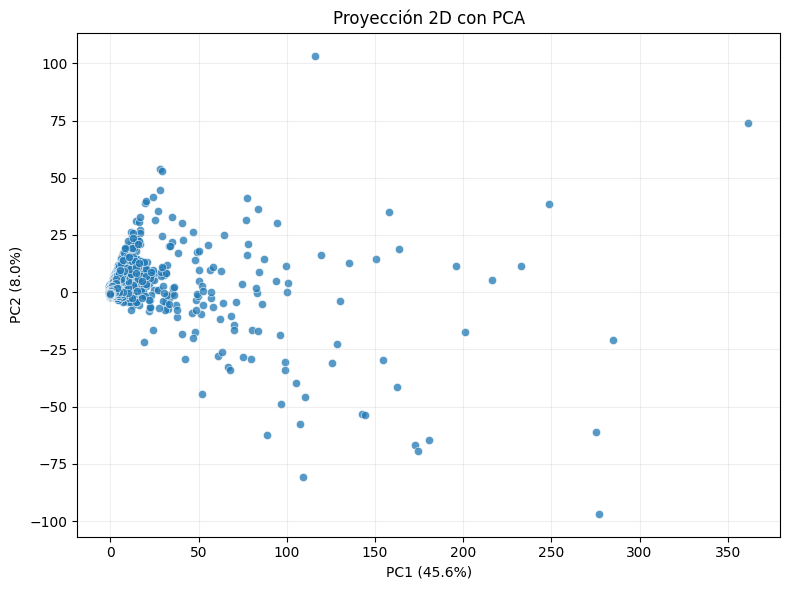

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_std = StandardScaler().fit_transform(X_sel)

# 2) PCA a 2D
pca2 = PCA(n_components=2, random_state=42)
Z_pca = pca2.fit_transform(X_std)

pca_df = pd.DataFrame(Z_pca, columns=['PC1', 'PC2'])
print("Varianza explicada PC1+PC2:", pca2.explained_variance_ratio_.sum().round(4))

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', s=35, alpha=0.75)
plt.title('Proyección 2D con PCA')
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
